<a href="https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-08/08-09-Project-Transformer-Book-Review-Classification-with-DistilBERT-and-Hugging-Face.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Goal: Build, fine-tune, and evaluate a pre-trained DistilBERT Transformer model for binary book review sentiment classification using the Hugging Face Transformers library. This end-to-end Project 2 demonstrates loading and sampling the IMDb sentiment dataset, tokenizing text with a pretrained tokenizer, configuring and fine-tuning a DistilBERT sequence classification model using the Trainer API, evaluating model performance, and applying modern transfer learning techniques for natural language processing.

## Step 1: Install & Import Dependencies

We'll use the `transformers` and `datasets` libraries for pre-trained models and data, and PyTorch for modeling.

In [46]:
# Import essential libraries for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Verify successful imports and display versions
print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name()}")
else:
    print("Running on CPU")

All libraries imported successfully!
PyTorch version: 2.11.0+cu128
NumPy version: 2.0.2
GPU available: Tesla T4


In [47]:
# Install necessary libraries (uncomment on Colab)
!pip install -q -U datasets transformers huggingface_hub
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import torch

## Step 2: Load and Prepare Dataset

We'll use the IMDb dataset. (You could use this code for book reviews too!) To keep things quick, we'll load just 1% for demo purposes.

In [48]:
from datasets import load_dataset
from collections import Counter

print("Loading dataset...")

full_train_dataset = load_dataset(
    "stanfordnlp/imdb",
    split="train"
)

full_test_dataset = load_dataset(
    "stanfordnlp/imdb",
    split="test"
)

# Randomly select 250 examples from each split.
# Shuffling prevents us from accidentally selecting only one class.
imdb_train_dataset = (
    full_train_dataset
    .shuffle(seed=42)
    .select(range(250))
)

imdb_test_dataset = (
    full_test_dataset
    .shuffle(seed=42)
    .select(range(250))
)

print("Dataset loaded.")

print("Training label counts:", Counter(imdb_train_dataset["label"]))
print("Test label counts:", Counter(imdb_test_dataset["label"]))

Loading dataset...
Dataset loaded.
Training label counts: Counter({0: 129, 1: 121})
Test label counts: Counter({0: 129, 1: 121})


## Step 3: Tokenize Text

This step converts text into numbers using a tokenizer from DistilBERT.

In [49]:
print("Tokenizing dataset...")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length")

train_encodings = imdb_train_dataset.map(tokenize_function, batched=True)
test_encodings = imdb_test_dataset.map(tokenize_function, batched=True)
print("Dataset tokenized.")

Tokenizing dataset...
Dataset tokenized.


## Step 4: Load Pre-trained Model for Sequence Classification

Now, we load DistilBERT with two output labels.

In [50]:
print("Loading model...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
print("Model loaded.")

Loading model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


## Step 5: Define Training Arguments for Hugging Face Trainer

Set your batch size, number of epochs, learning rate, logging, and checkpointing.

In [51]:
from transformers import TrainingArguments

print("Defining training arguments...")
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_steps=10,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
)

Defining training arguments...


## Step 6: Train the Model Using Hugging Face Trainer

This will run the training loop, evaluate, log, and save models for us.

In [52]:
print("Initializing Trainer and starting training...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=test_encodings,
    processing_class=tokenizer,
)

trainer.train()

print("Training complete.")

Initializing Trainer and starting training...


Epoch,Training Loss,Validation Loss
1,0.668901,0.657637
2,0.534722,0.607395
3,0.448453,0.563932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


Evaluating the fine-tuned model...


Test accuracy: 0.7200

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.76      0.74       129
    Positive       0.73      0.68      0.70       121

    accuracy                           0.72       250
   macro avg       0.72      0.72      0.72       250
weighted avg       0.72      0.72      0.72       250



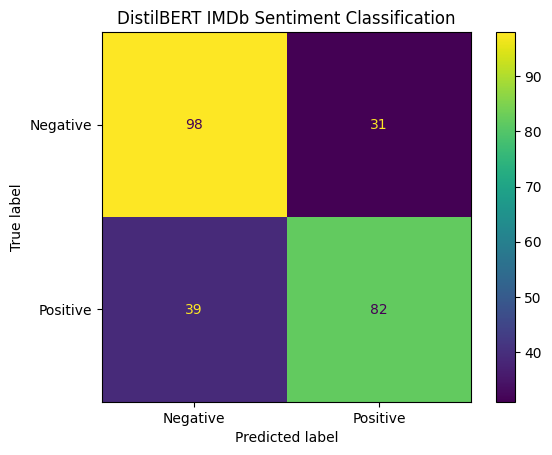

In [53]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

print("Evaluating the fine-tuned model...")

prediction_output = trainer.predict(test_encodings)

predicted_labels = np.argmax(
    prediction_output.predictions,
    axis=1
)

true_labels = np.array(
    test_encodings["label"]
)

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(f"Test accuracy: {accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    labels=[0, 1],
    display_labels=["Negative", "Positive"],
)

plt.title("DistilBERT IMDb Sentiment Classification")
plt.show()